# Intraday Pairs Trading: walkthrough

This notebook walks through the results produced by the pipeline. It only **reads** `results/`, so it runs in seconds.
To recompute everything:

```bash
python scripts/download_data.py --databento-key YOUR_KEY
python scripts/build_data.py
python scripts/run_pipeline.py
```

**Research question:** can a market-neutral pairs portfolio, selected with cointegration tests on 1-minute data for 100 US stocks, earn a positive risk-adjusted return *out of sample* after realistic costs? Which bar size and hedge-ratio method work best?

In [1]:
import json
import pandas as pd
from IPython.display import Image

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
pd.set_option("display.width", 160)
R = "../results/"
meta = json.load(open(R + "run_meta.json"))
print("Chosen on validation:", meta["config_label"])
print("Variants tried:", meta["n_trials"])

Chosen on validation: Rolling OLS hedge, 1 day bars, enter at z = ±2, exit at ±0.5
Variants tried: 108


## 1. Data
Databento Nasdaq 1-minute bars, regular session only. The build step detects each day's session end, back-adjusts prices for splits and spin-offs, drops recycled symbols, and cross-checks closes against Yahoo.

In [2]:
pd.Series(meta["data"])

,0
n_tickers,100
n_days,1255
n_minutes,462330
first_day,2020-11-06
last_day,2025-11-05
n_split_events,22
n_overnight_jumps,69
n_jumps_explained,16
n_days_session_to_1500,422
n_days_early_close,10


In [3]:
summary = pd.read_csv(R + "data_summary.csv")
summary[summary["group"].notna()].sort_values("median_nasdaq_dollar_vol_m", ascending=False).head(10)

,ticker,group,first_day,days_traded,avg_minutes_with_trade,median_nasdaq_dollar_vol_m,median_price,median_abs_diff_bps,share_within_50bps,n_days
92,TSLA,"EVs, autos & batteries",2020-11-06,1255,368.400,"3,250.000",244.600,1.546,1.000,823.000
59,NVDA,Semiconductors,2020-11-06,1255,368.400,"2,060.000",31.500,1.477,1.000,823.000
1,AAPL,Tech hardware,2020-11-06,1255,368.400,"1,679.000",172.600,1.308,1.000,823.000
54,MSFT,Software,2020-11-06,1255,368.400,"1,359.000",326.000,1.126,0.999,823.000
3,AMZN,Internet retail,2020-11-06,1255,368.400,"1,312.000",163.700,1.358,1.000,823.000
51,META,Interactive media,2022-06-09,856,370.800,"1,017.000",464.600,1.112,0.724,596.000
32,GOOGL,Interactive media,2020-11-06,1255,368.300,771.300,136.000,1.187,1.000,823.000
2,AMD,Semiconductors,2020-11-06,1255,368.400,769.400,109.300,1.226,1.000,823.000
31,GOOG,Interactive media,2020-11-06,1255,368.000,672.800,136.800,1.078,1.000,823.000
20,CRWV,AI cloud,2025-03-28,154,385.000,466.100,119.400,2.679,0.181,150.000


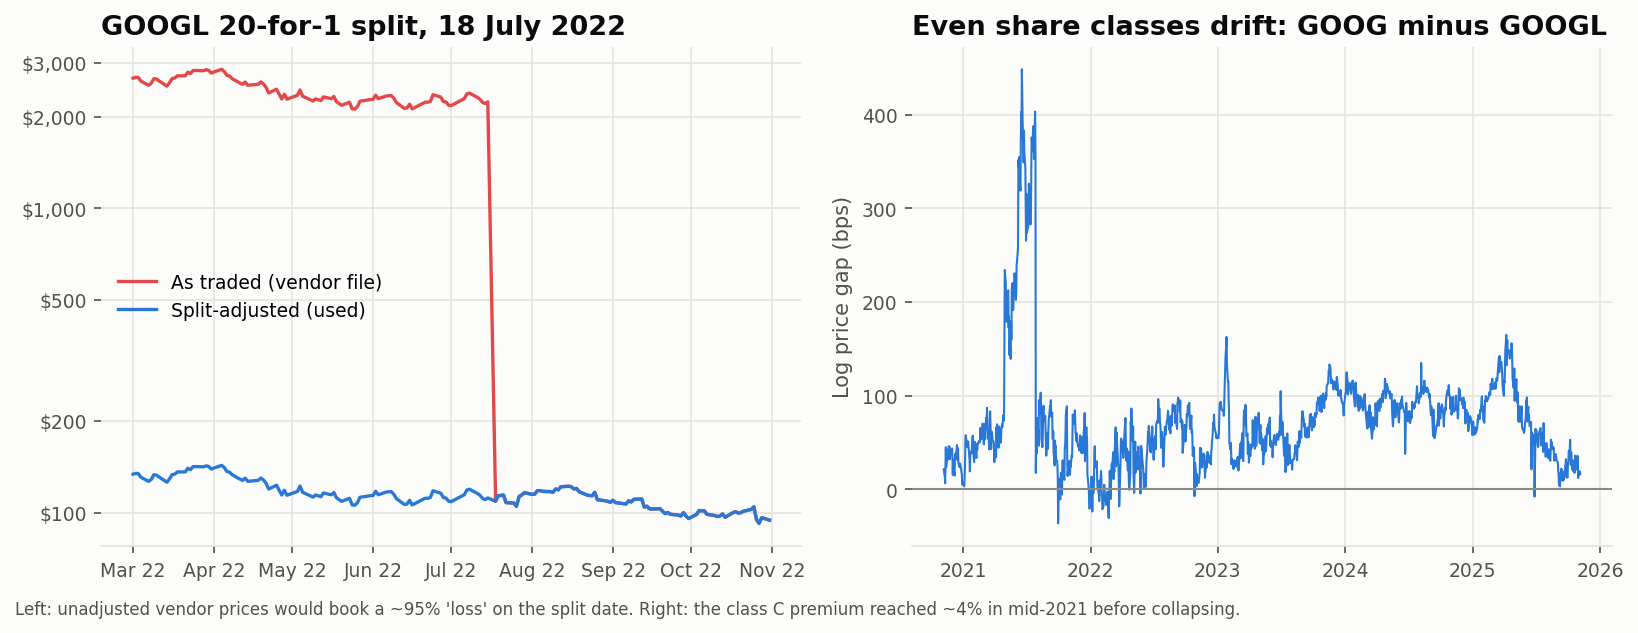

In [4]:
Image(R + "figures/fig10_data_quality.png")

## 2. Pair selection
Every month, all within-industry pairs are tested on the previous 6 months of 30-minute bars. The Engle-Granger and Johansen tests are implemented in `src/pairs/coint.py` and validated by Monte Carlo in `tests/`.

In [5]:
pd.read_csv(R + "selection_funnel.csv")

,step,count
0,Within-industry candidate pair-months,5765
1,"Engle-Granger p <= 5% (both orderings, Bonferroni)",334
2,... and Johansen trace test rejects r = 0,216
3,... and half-life 2 h - 10 days,216
4,... and Hurst < 0.5 and plausible hedge ratio (eligible),137
5,"Selected (top 5 / month, ticker cap)",117
6,Benjamini-Hochberg discoveries at 5% FDR (all candidates),9


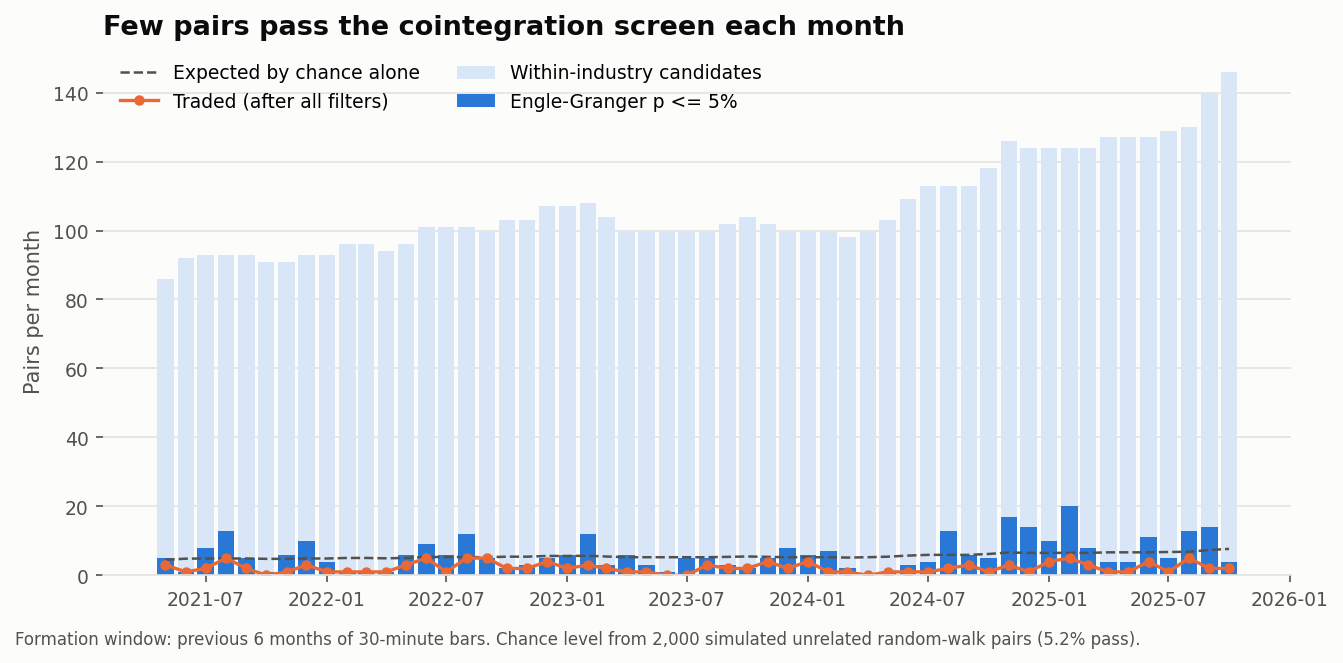

In [6]:
Image(R + "figures/fig2_selection_by_month.png")

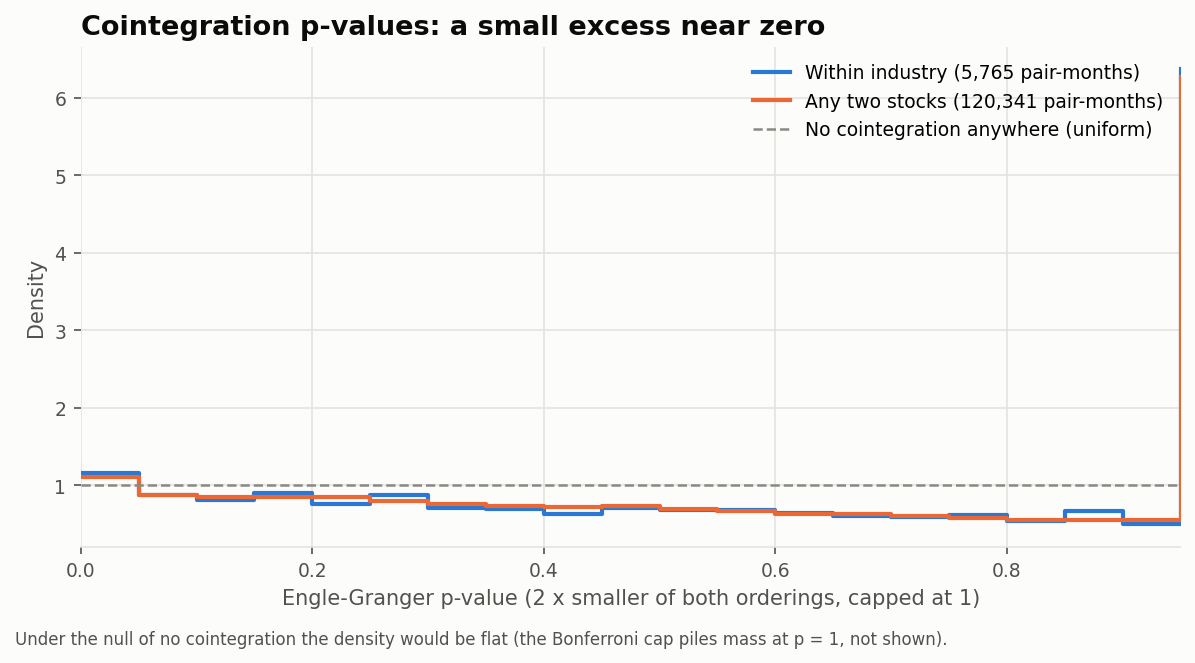

In [7]:
Image(R + "figures/fig3_pvalue_histogram.png")

Does cointegration found in the formation window persist? Each pair is re-tested on the following 6 months.

In [8]:
pd.read_csv(R + "cointegration_persistence.csv")

,eligible,n,share_p5_next,median_p_next,median_hl_form,median_hl_next,median_abs_beta_change
0,Other candidates (random sample),960,0.052,0.685,53.813,51.905,0.394
1,Eligible (passed all filters),115,0.104,0.470,17.953,45.935,0.342


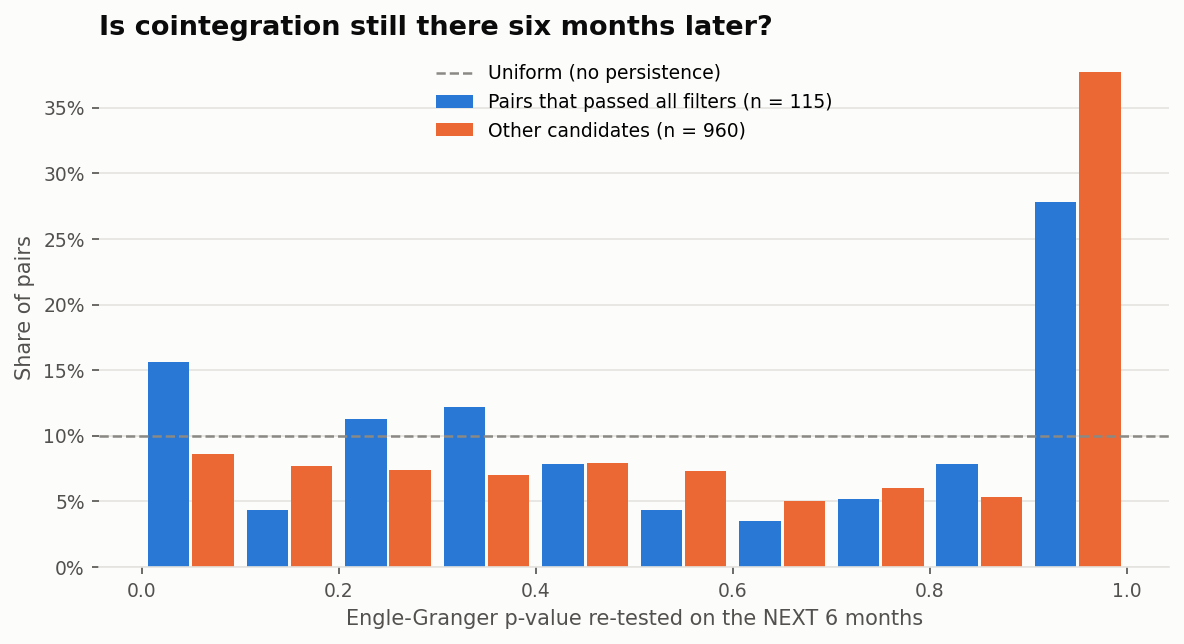

In [9]:
Image(R + "figures/fig8_persistence.png")

## 3. Walk-forward backtest
- **Parameter choice.** 108 variants (bar size x hedge method x entry z x exit z) are run. The one with the best **2021-05 to 2022-12** net Sharpe is chosen, and 2023-01 to 2025-10 is reported as out of sample.
- **Fills.** Orders fill 1 minute after the signal bar closes.
- **Costs.** Each fill pays half the spread (at least half a tick), commission and impact. The short leg also pays a borrow fee.

In [10]:
perf = pd.read_csv(R + "performance.csv")
perf[["period", "series", "cagr", "vol", "sharpe", "sharpe_ci_low", "sharpe_ci_high", "max_dd", "ff6_alpha_ann", "ff6_alpha_t", "beta_spy"]]

,period,series,cagr,vol,sharpe,sharpe_ci_low,sharpe_ci_high,max_dd,ff6_alpha_ann,ff6_alpha_t,beta_spy
0,validation,Strategy (net),0.146,0.084,1.662,0.715,2.626,-0.066,0.150,2.354,0.091
1,validation,Strategy (gross),0.158,0.084,1.781,0.863,2.758,-0.062,0.160,2.509,0.091
2,validation,Average of all 108 variants (net),0.054,0.053,1.020,-0.295,2.228,-0.048,0.057,1.628,0.052
3,validation,SPY buy & hold,-0.036,0.203,-0.117,-1.318,1.327,-0.245,0.002,0.187,1.000
4,oos,Strategy (net),0.031,0.086,0.393,-0.735,1.516,-0.099,0.015,0.301,0.108
5,oos,Strategy (gross),0.044,0.086,0.541,-0.587,1.666,-0.093,0.028,0.548,0.107
6,oos,Average of all 108 variants (net),-0.066,0.071,-0.920,-2.120,0.034,-0.218,-0.074,-1.651,0.032
7,oos,SPY buy & hold,0.244,0.155,1.158,0.118,2.279,-0.188,-0.006,-1.311,1.000
8,full,Strategy (net),0.072,0.086,0.858,0.039,1.614,-0.099,0.069,1.710,0.098
9,full,Strategy (gross),0.085,0.086,0.995,0.187,1.752,-0.093,0.081,1.992,0.098


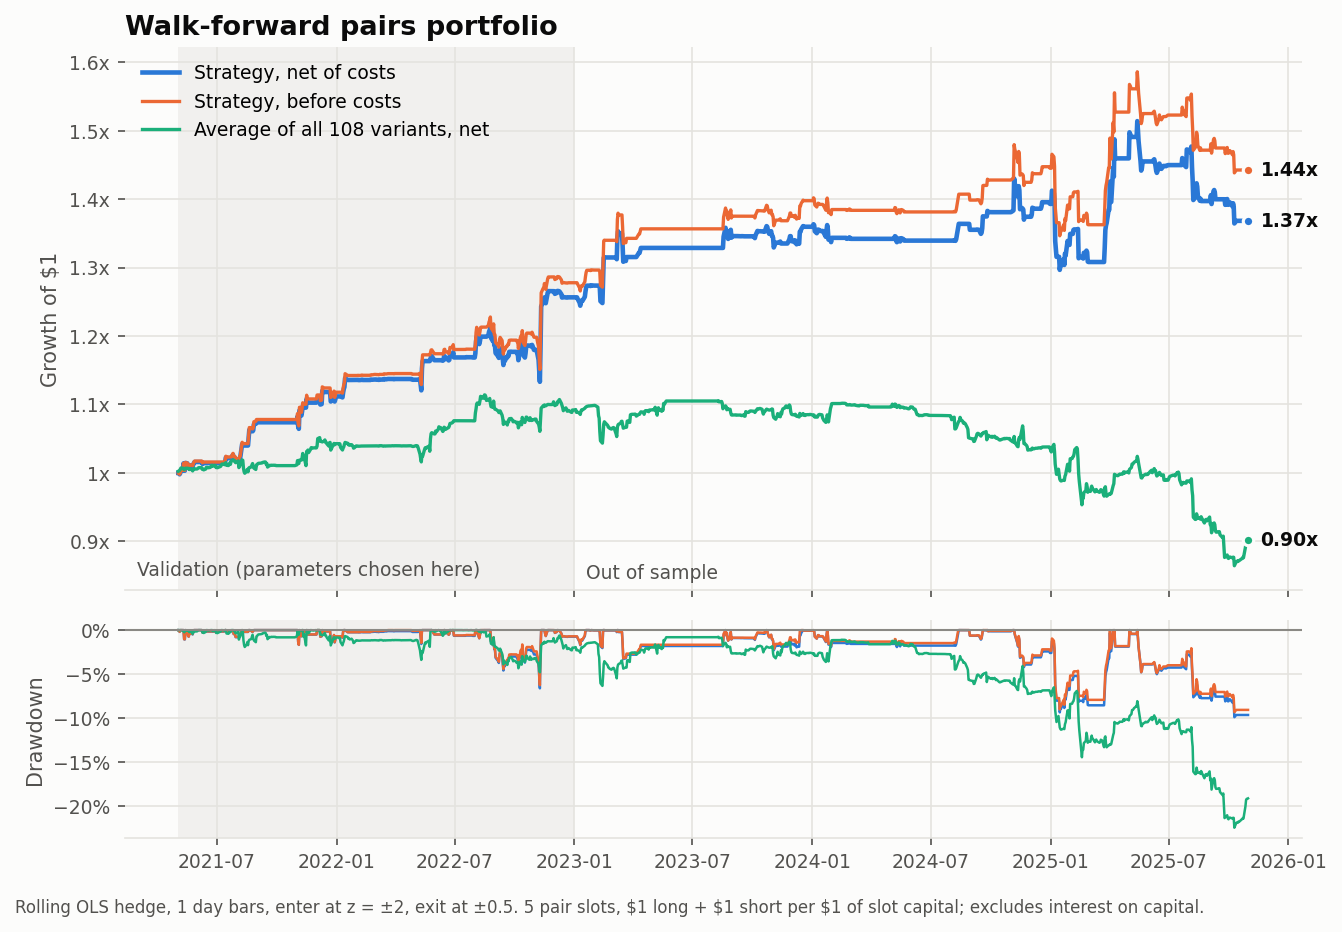

In [11]:
Image(R + "figures/fig1_equity.png")

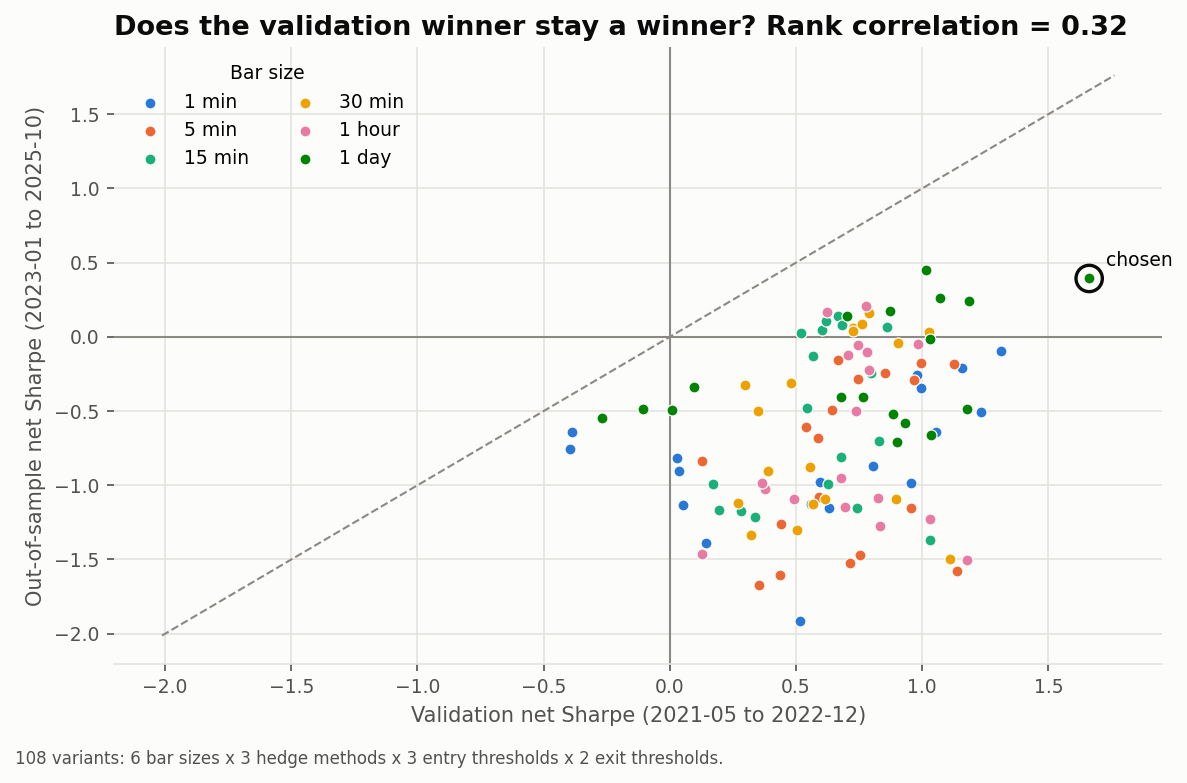

In [12]:
Image(R + "figures/fig4_validation_vs_oos.png")

In [13]:
grid = pd.read_csv(R + "grid_results.csv")
grid.sort_values("validation_sharpe", ascending=False)[["bar", "method", "entry", "exit", "validation_sharpe", "oos_sharpe", "n_trades"]].head(10)

,bar,method,entry,exit,validation_sharpe,oos_sharpe,n_trades
99,1D,rolling,2.000,0.500,1.662,0.393,147
2,1min,static,2.000,0.000,1.312,-0.093,153
4,1min,static,2.500,0.000,1.232,-0.506,108
98,1D,rolling,2.000,0.000,1.185,0.245,143
79,1h,rolling,1.500,0.500,1.179,-1.502,506
103,1D,kalman,1.500,0.500,1.176,-0.485,182
0,1min,static,1.500,0.000,1.157,-0.212,222
25,5min,rolling,1.500,0.500,1.140,-1.580,820
20,5min,static,2.000,0.000,1.128,-0.181,147
61,30min,rolling,1.500,0.500,1.108,-1.495,577


## 4. What drives the result?

In [14]:
pd.read_csv(R + "bar_size_study.csv")

,bar,oos_gross_sharpe_avg,oos_net_sharpe_avg,full_gross_sharpe_avg,full_net_sharpe_avg,chosen_rules_full_gross,chosen_rules_full_net,chosen_rules_oos_net,trades_per_month,gross_bps_per_trade,cost_bps_per_trade,break_even_cost_multiplier,break_even_leg_cost_bps
0,1min,-0.504,-0.818,-0.044,-0.345,-0.068,-0.488,-1.156,11.444,-1.250,7.416,,
1,5min,-0.578,-0.850,-0.073,-0.335,-0.359,-0.698,-1.524,8.926,-8.750,7.864,,
2,15min,-0.306,-0.552,0.063,-0.173,-0.088,-0.391,-1.150,7.870,-2.350,7.697,,
3,30min,-0.401,-0.619,-0.008,-0.222,-0.075,-0.353,-1.090,7.148,-2.167,7.671,,
4,1h,-0.485,-0.690,-0.055,-0.255,-0.130,-0.390,-1.224,6.296,-4.134,7.736,,
5,1D,-0.100,-0.222,0.195,0.078,0.995,0.858,0.393,2.722,65.089,8.243,7.806,32.171


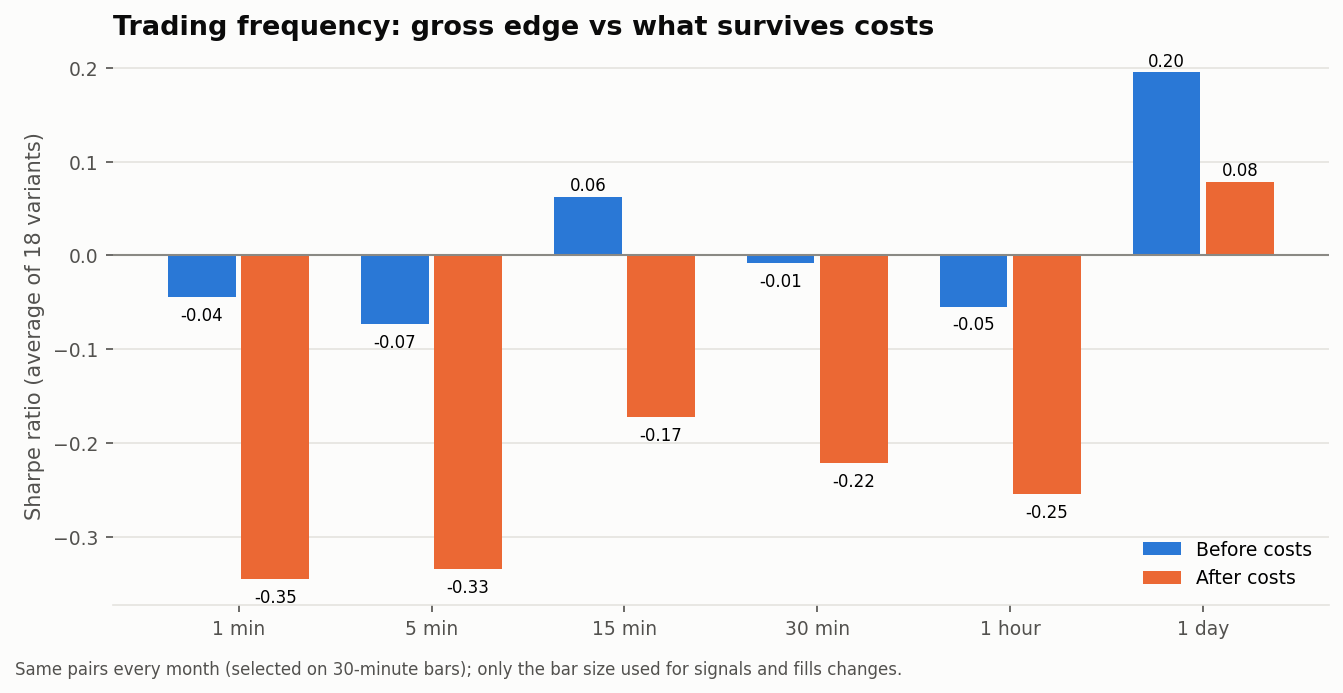

In [15]:
Image(R + "figures/fig5_bar_size.png")

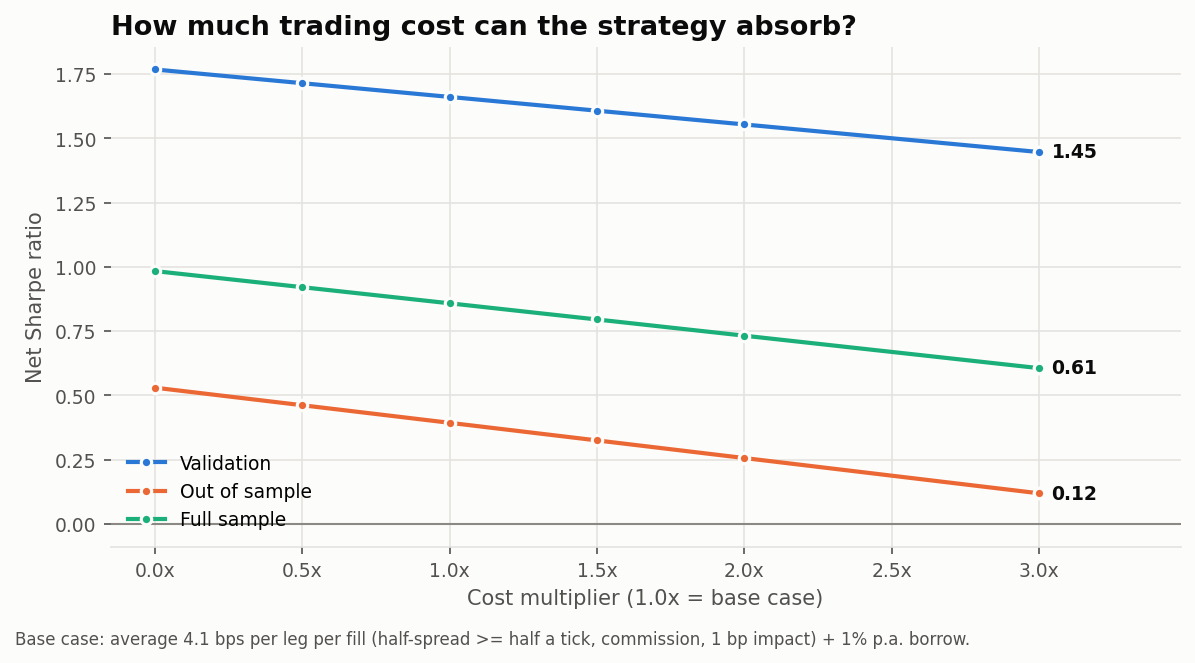

In [16]:
Image(R + "figures/fig6_cost_sensitivity.png")

In [17]:
pd.read_csv(R + "latency.csv")

,fill,full_net_sharpe,full_gross_sharpe,oos_net_sharpe
0,"At the signal bar's closing price (no delay, optimistic)",0.484,0.619,-0.125
1,Close of the next 1-minute bar (base case),0.858,0.995,0.393
2,5 minutes after the signal,0.888,1.029,0.418
3,15 minutes after the signal,0.801,0.941,0.374
4,Close of the next bar,0.444,0.583,-0.075


In [18]:
pd.read_csv(R + "hedge_method_study.csv").pivot(index="bar", columns="method", values="oos_sharpe")

method,kalman,rolling,static
bar,,,
15min,-0.666,-1.069,0.078
1D,-0.385,0.276,-0.556
1h,-0.837,-1.241,0.009
1min,-0.872,-1.239,-0.342
30min,-0.743,-1.170,0.056
5min,-0.699,-1.520,-0.332


In [19]:
pd.read_csv(R + "selection_methods.csv")

,selection,full,oos,validation
0,"Cointegration, within industry (strategy)",0.858,0.393,1.662
1,Distance / SSD (Gatev et al.),-0.107,-0.662,0.769
2,"Cointegration, any industry",1.357,1.583,1.109
3,Random within-industry pairs (median of 100),0.004,-0.062,0.096


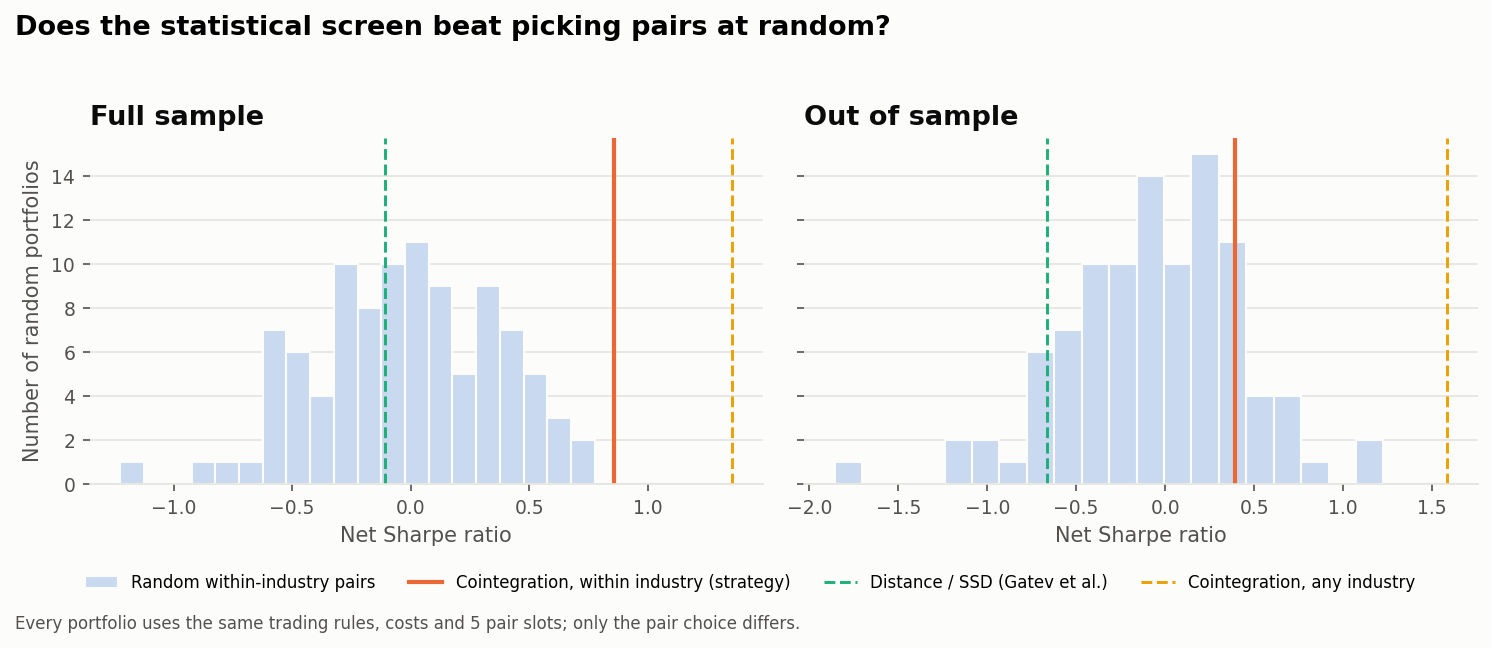

In [20]:
Image(R + "figures/fig7_selection_placebo.png")

In [21]:
pd.read_csv(R + "by_year.csv")

,year,strategy_net_return,strategy_gross_return,all_variants_net_return,spy_return,strategy_net_sharpe,strategy_gross_sharpe,all_variants_net_sharpe,spy_sharpe,months
0,2021,0.112,0.118,0.043,0.150,2.355,2.471,1.211,1.752,May-Dec
1,2022,0.130,0.143,0.047,-0.182,1.352,1.473,0.890,-0.710,Jan-Dec
2,2023,0.082,0.094,-0.005,0.262,1.289,1.469,-0.086,1.858,Jan-Dec
3,2024,0.025,0.034,-0.046,0.249,0.479,0.652,-0.943,1.832,Jan-Dec
4,2025,-0.018,-0.002,-0.130,0.174,-0.100,0.049,-1.525,1.038,Jan-Oct


In [22]:
pd.read_csv(R + "by_industry.csv")

,group,trades_oos,trades_validation,net_pnl_pct_of_capital_oos,net_pnl_pct_of_capital_validation
0,Semiconductors,21.000,27.000,-10.150,4.450
1,Pharma,2.000,0.000,-1.240,0.000
2,Bitcoin miners / hosting,10.000,0.000,-0.240,0.000
3,Solar,0.000,1.000,0.000,0.720
4,Travel,0.000,1.000,0.000,-0.400
5,Household products,4.000,0.000,0.330,0.000
6,Ride-hailing,3.000,0.000,0.330,0.000
7,Tech hardware,2.000,0.000,1.170,0.000
8,Biotech,2.000,0.000,1.470,0.000
9,Interactive media,18.000,23.000,1.750,-1.730


In [23]:
pd.read_csv(R + "trade_stats.csv")

,period,n_trades,trades_per_month,win_rate,median_hold_hours,gross_bps_per_trade,cost_bps_per_trade,avg_leg_cost_bps,exit_reversion,exit_month_end,exit_time_stop,exit_stop_loss
0,validation,66.000,3.300,0.636,120.000,95.099,5.717,2.858,0.651,0.167,0.151,0.030
1,oos,81.000,2.382,0.543,120.000,40.637,10.301,5.150,0.518,0.161,0.173,0.148
2,full,147.000,2.722,0.585,120.000,65.089,8.243,4.121,0.578,0.163,0.163,0.095


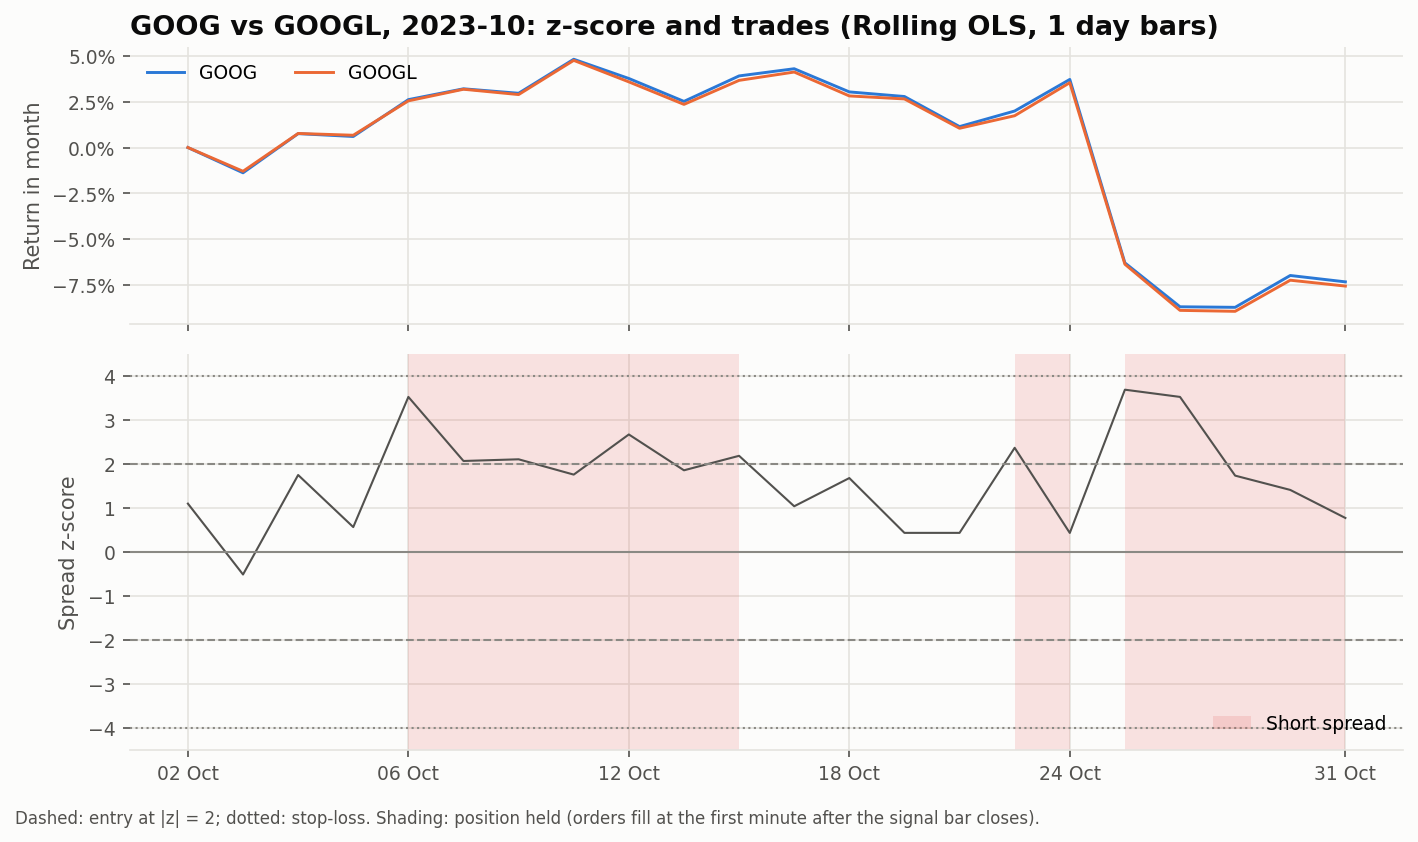

In [24]:
Image(R + "figures/fig9_example_pair.png")

## 5. Takeaways
See the README for the full discussion. In short:
- Cointegration among these stocks is only slightly more common than chance would predict.
- The configuration that looked best on 2021-22 data weakened sharply out of sample.
- Trading at higher frequency raises turnover faster than it raises the gross edge.